In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'patients_lme_DTI.tsv'), sep = '\t')
df['Week'] = df['week'].str.extract(r'(\d+)') # get numeric values
df['region_bilat'] = df['regionname'].str[:3]


df['side'] = 'ipsilesional'
is_cst=df['region_bilat'] == 'CST'
df.loc[is_cst & (df.regionname.str[-1] == 'L'), 'side'] = 'contralesional'
df.loc[~is_cst & (df.regionname.str[-1] == 'L'), 'side'] = 'contralesional'

# sort weeks!!
df['Week'] = df['Week'].astype(int)
df=df.sort_values('Week')


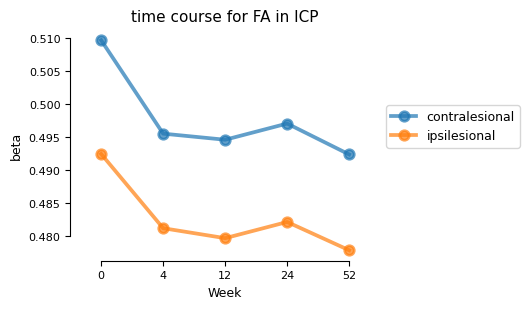

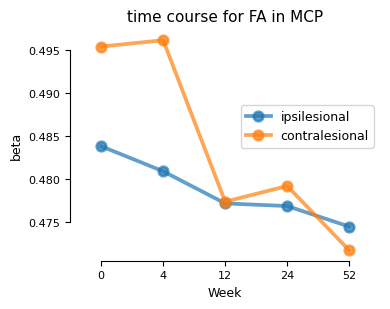

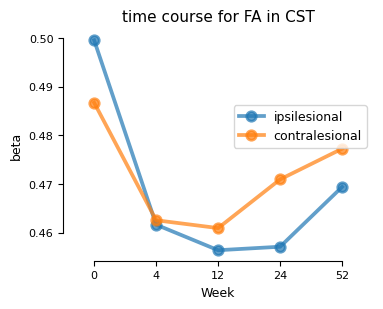

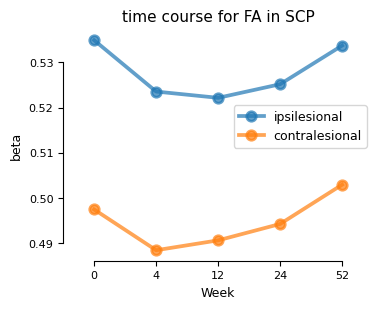

In [2]:
for region in df.region_bilat.unique():
    fig, ax = plt.subplots(figsize = (4,3))
    sns.pointplot(x = 'Week', y = 'beta', data = df[df.region_bilat == region], hue = 'side', alpha = .7)

    ax.legend(bbox_to_anchor = (1, .7))
    sns.despine(trim = True)
    plt.title(f"time course for FA in {region}")
    plt.show()
